In [149]:
import tensorflow as tf 
print(tf.__version__)

2.21.0


In [150]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 

In [151]:
df=pd.read_csv('Churn_Modelling.csv')

In [152]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [153]:
df.shape

(10000, 14)

In [154]:
X=df.iloc[:,3:13]

In [155]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [156]:
y=df.iloc[:,-1]

In [157]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [158]:
geography=pd.get_dummies(X['Geography'],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)

In [159]:
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [160]:
X.drop(["Geography","Gender"],axis=1,inplace=True)

In [161]:
pd.concat([X,geography,gender],axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [162]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=0)

In [163]:
from sklearn.preprocessing import StandardScaler

In [164]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [165]:
X_train.shape

(8000, 8)

In [166]:
X_test.shape

(2000, 8)

In [167]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [168]:
###Create Artificial Neural Network

In [169]:
from  tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

###Initialilize the ANN


In [170]:
classifier= Sequential()

In [171]:
#Adding the input layers
classifier.add(Dense(units=11 , activation='relu'))

In [172]:
#Adding the first Hidden layer
classifier.add(Dense(units=7 , activation="relu"))
classifier.add(Dropout(0.2))

In [173]:
# Adding the second Hidden layer
classifier.add(Dense(units=6,activation="relu"))
classifier.add(Dropout(0.3))

In [174]:
#adding the output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [175]:
classifier.compile(optimizer=opt, loss="binary_crossentropy" , metrics=['accuracy'])

In [176]:
opt=tf.keras.optimizers.Adam(learning_rate=0.01)

In [177]:
#early Stopping
# early_stopping=tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     min_delta=0.0001,
#     patience=0,
#     verbose=1,
#     mode="auto",
#     baseline=None,
#     restore_best_weights=False,
#     start_from_epoch=0,
# )


In [178]:
model_history= classifier.fit(X_train,y_train,validation_split=0.33,batch_size=32,epochs=1000)

Epoch 1/1000


168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7946 - loss: 0.5037 - val_accuracy: 0.7955 - val_loss: 0.4422
Epoch 2/1000
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4394 - val_accuracy: 0.8201 - val_loss: 0.4124
Epoch 3/1000
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8115 - loss: 0.4213 - val_accuracy: 0.8141 - val_loss: 0.4028
Epoch 4/1000
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8110 - loss: 0.4210 - val_accuracy: 0.8258 - val_loss: 0.3972
Epoch 5/1000
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8082 - loss: 0.4151 - val_accuracy: 0.8167 - val_loss: 0.4058
Epoch 6/1000
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.4107 - val_accuracy: 0.8300 - val_loss: 0.3877
Epoch 7/1000
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8210 - loss: 0.4013 - val_accuracy: 0.8376 - val_loss: 0.3863
Epoch 8/1000
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8332 - loss: 0.3908 - val_accuracy:

In [179]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

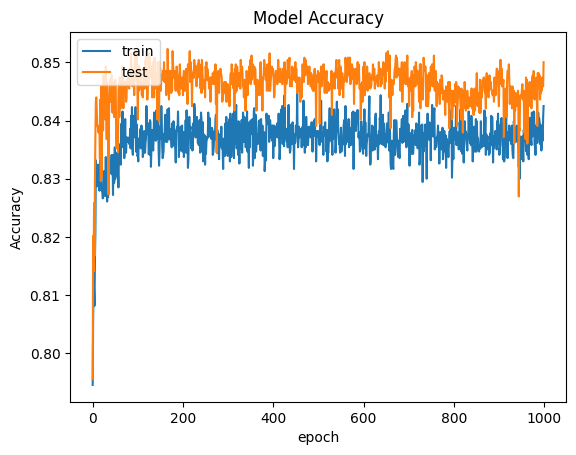

In [189]:
plt.plot(model_history.history["accuracy"])
plt.plot(model_history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("epoch")
plt.ylabel("Accuracy")
plt.legend(['train','test'],loc="upper left")
plt.show()


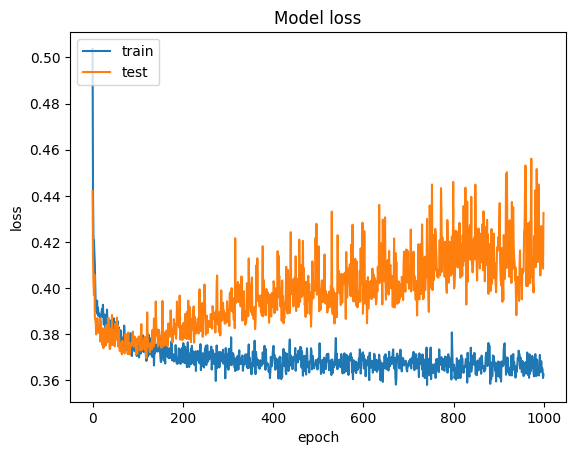

In [190]:
plt.plot(model_history.history["loss"])
plt.plot(model_history.history["val_loss"])
plt.title("Model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['train','test'],loc="upper left")
plt.show()

# making the prediction and evaluating the model

In [191]:
y_pred=classifier.predict(X_test)
y_pred=(y_pred>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [183]:
#make the confusion matrix

In [192]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

In [193]:
cm

array([[1542,   53],
       [ 223,  182]])

In [194]:
from sklearn.metrics import accuracy_score

score=accuracy_score(y_test,y_pred)

In [195]:
score*100

86.2

In [196]:
classifier.get_weights()

[array([[ 1.5152066 , -1.3945423 ,  0.11363927, -0.5394681 , -0.7941852 ,
         -2.8774908 , -0.33149758,  0.13373269, -0.4605438 , -3.5039215 ,
         -1.288036  ],
        [-2.8765044 ,  1.6940645 , -2.3842278 ,  2.270677  ,  7.624183  ,
          4.501289  ,  5.0369925 , -1.8370409 ,  0.74728924,  0.74431807,
         -6.1114316 ],
        [-0.43186012, -0.37356612, -1.3673903 ,  1.2135695 , -0.10058404,
         -0.4852708 ,  0.5639858 ,  0.4093946 ,  0.887891  ,  0.779831  ,
          1.0030277 ],
        [-0.85745126, -4.967533  , -2.502179  , -1.0605435 ,  0.20978704,
          1.7351797 , -0.5182733 ,  1.420666  , -5.2749314 ,  1.8883574 ,
         -1.1293169 ],
        [ 4.2275357 , -6.2590685 , -1.7526256 ,  7.110609  , -2.0375097 ,
         -0.5399613 ,  0.15368985,  6.1732335 ,  2.646034  ,  2.5670671 ,
          1.0336593 ],
        [ 1.4152178 ,  0.539876  ,  1.2451277 , -0.7558411 , -0.64906216,
         -0.8030763 ,  0.02914258,  0.31251362, -1.2263949 , -1.7725985